## Analyzing the dataset

Original work by Melina Paxinou and Martha Koukourikou

In [1]:
file = "el_en_mt_dataset.tsv"

In [7]:
import pandas as pd
import stanza 
content = pd.read_csv(file, sep="\t", header = 0, keep_default_na=False)
print(content[0:5])

    SL   TL                                                 ST  \
0  ell  eng  Κολυμπάει τώρα στη θάλασσα, ενώ οι φίλοι του κ...   
1  ell  eng  Μείνε μαζί μας απόψε για φαγητό και κουβέντα, ...   
2  ell  eng  Μοιράζεται ένα φωτεινό δωμάτιο με την αδελφή τ...   
3  ell  eng  Μου έπεσαν τα μαλλιά από την έκπληξη όταν μου ...   
4  ell  eng  Μούσκεψε μια μεγάλη πετσέτα για να καθαρίσει τ...   

                                                  TT  
0  He's swimming in the sea now, while his friend...  
1  Stay with us tonight for dinner and a chat, an...  
2  She shares a bright room with her sister, whic...  
3  My hair fell out from surprise when they told ...  
4  She wetted a large towel to clean her hands af...  


In [9]:
sl_column = content.iloc[:,[2]]
tl_column = content.iloc[:,[3]]
print(tl_column[:1])

                                                  TT
0  He's swimming in the sea now, while his friend...


## Processing Greek text with Stanza

In [11]:
language = "el"
stanza.download(language)
nlp = stanza.Pipeline(language)

2025-01-15 11:46:07 INFO: Downloaded file to C:\Users\melou\stanza_resources\resources.json
2025-01-15 11:46:07 INFO: Downloading default packages for language: el (Greek) ...


2025-01-15 11:46:25 INFO: Downloaded file to C:\Users\melou\stanza_resources\el\default.zip
2025-01-15 11:46:26 INFO: Finished downloading models and saved to C:\Users\melou\stanza_resources
2025-01-15 11:46:26 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2025-01-15 11:46:26 INFO: Downloaded file to C:\Users\melou\stanza_resources\resources.json
2025-01-15 11:46:27 INFO: Loading these models for language: el (Greek):
| Processor | Package      |
----------------------------
| tokenize  | gdt          |
| mwt       | gdt          |
| pos       | gdt_nocharlm |
| lemma     | gdt_nocharlm |
| depparse  | gdt_nocharlm |

2025-01-15 11:46:27 INFO: Using device: cpu
2025-01-15 11:46:27 INFO: Loading: tokenize
2025-01-15 11:46:28 INFO: Loading: mwt
2025-01-15 11:46:28 INFO: Loading: pos
2025-01-15 11:46:29 INFO: Loading: lemma
2025-01-15 11:46:29 INFO: Loading: depparse
2025-01-15 11:46:30 INFO: Done loading processors!


In [13]:
source_text = content["ST"]
target_text = content["TT"]
for text in source_text[:1]:
    processed_st = nlp(text)
    print(processed_st)

[
  [
    {
      "id": 1,
      "text": "Κολυμπάει",
      "lemma": "κολυμπώ",
      "upos": "VERB",
      "xpos": "VERB",
      "feats": "Aspect=Imp|Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin|Voice=Act",
      "head": 0,
      "deprel": "root",
      "start_char": 0,
      "end_char": 9
    },
    {
      "id": 2,
      "text": "τώρα",
      "lemma": "τώρα",
      "upos": "ADV",
      "xpos": "ADV",
      "head": 1,
      "deprel": "advmod",
      "start_char": 10,
      "end_char": 14
    },
    {
      "id": [
        3,
        4
      ],
      "text": "στη",
      "start_char": 15,
      "end_char": 18
    },
    {
      "id": 3,
      "text": "σ",
      "lemma": "σε",
      "upos": "ADP",
      "xpos": "ADP",
      "head": 5,
      "deprel": "case",
      "start_char": 15,
      "end_char": 16
    },
    {
      "id": 4,
      "text": "τη",
      "lemma": "ο",
      "upos": "DET",
      "xpos": "DET",
      "feats": "Case=Acc|Gender=Fem|Number=Sing",
      "head": 5,


## Processing both Greek and English text with spaCy

In [16]:
import spacy
el_nlp= spacy.load('el_core_news_sm')
en_nlp= spacy.load('en_core_web_sm')

OSError: [E050] Can't find model 'el_core_news_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

In [ ]:
for text in source_text[:50]:
    el_doc = el_nlp(text)
    for token in el_doc:
        print(F'token: {token.text}\tpos: {token.pos_}\ttag: {token.tag_}\tdep: {token.dep_}')

## Identifying Greek diminutives

In [ ]:
suffix_list = ['άκι', 'ακίου', 'άκια', 'ακίων', 
               'ούλα', 'ούλας', 'ούλες', 'ουλών', 'ούλι',
               'ούλης', 'ούλη', 'ούληδες', 'ούληδων',
               'άκης', 'άκη', 'άκος', 'άκου', 'άκο', 'άκηδες', 'άκηδων',
               'ίτσα', 'ίτσας', 'ίτσες', 'ίτσων', 
               'ούδι', 'ούδια', 'όπουλο', 'όπουλου', 'οπούλα', 'οπούλας', 'οπούλες', 
               'ίσκος', 'ίσκου', 'ίσκοι', 'ίδιο']

In [ ]:
dim_list = []
suffix_lengths = [(suffix, len(suffix)) for suffix in suffix_list]

for text in source_text:
    el_doc = el_nlp(text)
    for token in el_doc:
        token_text = token.text
        for suffix, length in suffix_lengths:
            if token_text.endswith(suffix) and len(token) > length:
                dim_list.append(token)

print('Words that contain diminutive suffixes:', dim_list)

In [ ]:
dim_translations = []

suffix_lengths = [(suffix, len(suffix)) for suffix in suffix_list]

for source, target in zip(source_text, target_text):
    el_doc = el_nlp(source) 
    diminutive_words = []
    
    for token in el_doc:
        token_text = token.text
        for suffix, length in suffix_lengths:
            if token_text.endswith(suffix) and len(token) > length: 
                diminutive_words.append(token_text)
    
    if diminutive_words: 
        dim_translations.append((diminutive_words, target)) 

print("Diminutive words and their translations:")
for diminutive_words, translation in dim_translations:
    print(f"Greek diminutive words: {', '.join(diminutive_words)}")
    print(f"Translation sentence: {translation}")
    print("-" * 40)

## Identifying subject-to-verb ratio in both Greek and English

In [ ]:
from gr_nlp_toolkit import Pipeline
el_subjects = 0
gr_nlp = Pipeline("pos,dp") 
for text in source_text:
    try:
        doc = gr_nlp(text)
        for token in doc.tokens:
            if token.deprel and 'subj' in token.deprel:
                el_subjects += 1
    except KeyError as e:
        print(f"KeyError encountered: {e}")
        print(f"Text causing issue: {text}")
        continue 

print(el_subjects)

In [ ]:
el_verbs = 0
for text in source_text:
    try:
        doc = gr_nlp(text)
        for token in doc.tokens:
            if token.deprel and 'VERB' in token.upos:
                el_verbs += 1
    except KeyError as e:
        print(f"KeyError encountered: {e}")
        print(f"Text causing issue: {text}")
        continue  

print(el_verbs)

In [ ]:
en_subjects = 0
for text in target_text[:500]:
    en_doc = en_nlp(text)
    for token in en_doc:  
        if 'subj' in token.dep_:
            en_subjects += 1

print(en_subjects)

In [ ]:
en_verbs = 0
for text in target_text[:500]:
    en_doc = en_nlp(text)
    for token in en_doc:  
        if 'VERB' in token.pos_:
            en_verbs += 1

print(en_verbs)

## Average sentence length in tokens

In [36]:
for text in source_text:
    el_doc = el_nlp(text)
    tokens = [token for token in el_doc]
    length = len(tokens)
    # print(text, length)

total_tokens = 0
sentence_count = len(source_text)


for text in source_text:
    doc = el_nlp(text)  
    tokens = [token.text for token in doc]  
    total_tokens += len(tokens)  

average_token_length = total_tokens / sentence_count if sentence_count > 0 else 0

print(f"Average token length per sentence: {average_token_length:.2f}")

Average token length per sentence: 13.59


In [37]:
for text in target_text:
    en_doc = en_nlp(text)
    tokens = [token for token in en_doc]
    length = len(tokens)
    # print(text, length)

total_tokens = 0
sentence_count = len(source_text)

for text in target_text:
    doc = en_nlp(text)  
    tokens = [token.text for token in doc] 
    total_tokens += len(tokens) 

average_token_length = total_tokens / sentence_count if sentence_count > 0 else 0

print(f"Average token length per sentence: {average_token_length:.2f}")

Average token length per sentence: 14.71


## Words without direct translation equivalents

In [39]:
words_without_equivalents = ['μεράκι', 'καφενεί', 'καλημέρα', 'φιλότιμο', 'ρακί', 
                             'μεζεδάκι', 'τσίπουρ', 'παλικάρι', 'κομπολόι', 'πανηγύρι', 
                             'καφεν', 'γλέντι', 'βόλτ', 'τσιπουράκ', 'μοναχοπαίδι', 'σπουδαστ', 
                             'μονορούφι', 'μεγαλόψυχ', 'αυτολεξεί']

In [40]:
word_list = []
for text in source_text:
    el_doc = el_nlp(text)
    for token in el_doc:
        token_text = token.text
        if any(word in token_text for word in words_without_equivalents):
            word_list.append(token)

print('words_without_equivalents:', word_list)

words_without_equivalents: [μονορούφι, βόλτα, βόλτα, καφενείο, καλημέρα, φιλότιμο, πανηγύρια, παλικάρι, μεράκι, κομπολόι, καφενές, γλέντι, καφενείο, τσιπουράκι, μεζεδάκια, αυτολεξεί, βόλτα, βόλτα, βόλτα, βόλτα, ρακί, ρακί, ρακί, ρακί, ρακί, ρακί, ρακί, ρακί, φιλότιμο, φιλότιμο, φιλότιμο, μεζεδάκια, μεζεδάκια, μεζεδάκια, μεζεδάκια, μεζεδάκια, τσιπουράκι, τσιπουράκι, τσιπουράκι, τσιπουράκι, τσιπουράκι, πανηγύρι, πανηγύρι, πανηγύρι, πανηγύρι, μεράκι, μεράκι, μεράκι, μεράκι, μεράκι, γλέντι, γλέντι, γλέντι, γλέντι, γλέντι, καφενείο, καφενείο, καφενείο, καφενείο, καφενείο, κομπολόι, κομπολόι, κομπολόι, κομπολόι, κομπολόι, μεγαλόψυχος, μοναχοπαίδι, σπουδαστής]


In [41]:
word_translations = []

for source, target in zip(source_text, target_text):
    el_doc = el_nlp(source) 
    awesome_words = []
    
    for token in el_doc:
        token_text = token.text  
        if any(word in token_text for word in words_without_equivalents):
            awesome_words.append(token_text)  

    if awesome_words:  
        word_translations.append((awesome_words, target))  

print("Awesome words:")
for awesome_words, translation in word_translations:
    print(f"Greek words: {', '.join(awesome_words)}")
    print(f"Translation sentence: {translation}")
    print()

Awesome words:
Greek words: μονορούφι
Translation sentence: He drank the beer in one gulp, without even thinking to pair it with a few chips from the bowl.

Greek words: βόλτα
Translation sentence: It’s a beautiful day, isn’t it? We could go for a walk by the sea or sit outside for coffee.

Greek words: βόλτα
Translation sentence: Dimitris and Eleni went for a walk on the beach and ate ice creams from their favorite shop.

Greek words: καφενείο
Translation sentence: In the neighborhood café, elderly people usually gather to play cards and chat.

Greek words: καλημέρα
Translation sentence: The neighbor’s “good morning” was full of warmth and genuine kindness.

Greek words: φιλότιμο
Translation sentence: The volunteers’ sense of honor saved the event from disaster.

Greek words: πανηγύρια
Translation sentence: Summer in the village is full of festivals, music, and dancing.

Greek words: παλικάρι
Translation sentence: The young man did everything to help the old lady carry her belongings.

In [42]:
len(word_translations)

66

In [43]:
import re

pattern = r'\bξανά?[\w]{2,}'
other_words = []

for source, target in zip(source_text, target_text):
    el_doc = el_nlp(source)
    matches = re.findall(pattern, el_doc.text)
    other_words.extend(matches)

print(other_words)

['ξαναπούμε', 'ξανασχοληθείς', 'ξανασκεφτούμε', 'ξαναφτιάξω']


## Calculating sentence vectors for comparison

#### Greek-English reference and translation
Code inspired by Lab 5.4 of Language as Data, as taught by prof. Lucia Donatelli (December 2024)\
Vrije Universiteit Amsterdam, Faculty of Humanities, CLTL

In [52]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

C:\Users\melou\anaconda3\envs\LaD\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [54]:
def get_sentence_embedding(sentence, tokenizer, model):
    tokens = tokenizer.encode(sentence, add_special_tokens=True)
    model.eval() 
    tokens_tensor = torch.tensor(tokens).unsqueeze(0)
    output = model(tokens_tensor)
    vector = output[0].detach().numpy()[0]
    sentence_vector = np.mean(vector[1:-1], axis=0)
    return sentence_vector

In [56]:
source_sentences = [
    "Διαφωνείτε με την απόφαση που πήραμε και νομίζετε ότι πρέπει να το ξανασκεφτούμε πριν προχωρήσουμε;",
    "Άνοιξε το βιβλίο σου στη σελίδα εννιά και διάβασε δυνατά το πρώτο κεφάλαιο για να το ακούσουν όλοι.",
    "Άνοιξε το κουτάκι που κρατούσε στα χέρια της και βρήκε μέσα ένα δαχτυλίδι με μια μικρή πετρούλα.",
    "Συνήθως περνάει το δικό της, γιατί έχει έναν μοναδικό τρόπο να πείθει τους γύρω της με τα λόγια της.",
    "Είναι με το ένα πόδι στον τάφο, αλλά συνεχίζει να έχει πείσμα και δύναμη.",
    "Περάσαμε τις διακοπές μας στη Βοστόνη.",
    "Αγαπάει τα ζώα τόσο πολύ, που φροντίζει κάθε αδέσποτο που βρίσκει στον δρόμο, παρά τις δυσκολίες του.",
    "Αγαπάει τη βροχή και πάντα λέει πως του φέρνει ηρεμία όταν ακούει τον ήχο της στα παράθυρα.",
    "Αγαπάει την κηπουρική γιατί της θυμίζει τα καλοκαίρια που περνούσε μικρή στο σπίτι των παππούδων της στο χωριό.",
    "Αγκάλιασε τον Τομ πολύ σφιχτά, προσπαθώντας να τον παρηγορήσει μετά από την δύσκολη ημέρα που πέρασε.",
    "Αγόρασε ένα καπέλο με φαρδύ γείσο από το κατάστημα, για να προστατεύεται από τον ήλιο στις διακοπές.",
    "Απέτυχε στο σχέδιό του, αλλά αποφάσισε να μην τα παρατήσει.",
    "Διάβασε και απάντησε στις ερωτήσεις, γιατί πρέπει να καταλάβουμε αν το μάθημα είναι ξεκάθαρο ή αν χρειάζεται περισσότερη εξήγηση.",
    "Διδάσκει αγγλικά σε αρχάριους, αλλά επίσης προσπαθεί να τους μάθει να εκφράζονται πιο φυσικά και άνετα στην καθημερινή ζωή.",
    "Δουλεύει, αλλά πρέπει να το προσέχουμε συνεχώς για να μην υπάρξουν προβλήματα στο μέλλον.",
    "Δουλεύει σε μια τράπεζα και βοηθάει τους πελάτες να κατανοήσουν καλύτερα τα οικονομικά τους θέματα."
]

target_1 = [
    "Do you disagree with the decision we made, and think we should reconsider it before moving forward?",
    "Open your book on page nine and read the first chapter aloud for everyone to hear.",
    "She opened the small box she was holding in her hands and found a ring with a tiny stone inside.",
    "She usually gets her way because she has a unique way of persuading those around her with her words.",
    "He has one foot in the grave, but he still shows determination and strength.",
    "We spent our holiday in Boston.",
    "He loves animals so much that he takes care of every stray he finds on the street, despite his struggles.",
    "He loves the rain and always says that it brings him peace when he hears it on the windows.",
    "She loves gardening because it reminds her of the summers she spent as a child at her grandparents’ house in the village.",
    "She hugged Tom very tightly, trying to comfort him after the difficult day he had.",
    "He bought a hat with a wide brim from the store to protect himself from the sun on vacation.",
    "He failed in his plan, but he decided not to give up.",
    "Read and reply to the questions because we need to understand if the lesson is clear or if it needs further explanation.",
    "He teaches English to beginners, but he also tries to teach them how to express themselves more naturally and comfortably in everyday life.",
    "It's working, but we need to keep an eye on it constantly to avoid any problems in the future.",
    "She works in a bank and helps customers better understand their financial issues."
]

target_2 = [
    "Do you disagree with the decision we have made and do you think we need to think about it before we move forward?",
    "Open your book on page nine and read the first chapter so that everyone can hear it.",
    "He opened the pot that she held in her hands and found inside a ring with a small stone.",
    "She usually passes through her own, because she has a unique way to convince them around her with her words.",
    "He is with one foot in the tomb, but he continues to have persistence and strength.",
    "We spent our holidays in Boston.",
    "He loves the animals so much, that he takes care of every wreck he finds on the road, despite his difficulties.",
    "She loves the rain and always tells her that it brings her calm when she hears her sound in the windows.",
    "She loves gardening because she reminds her of the summer she spent little in the house of her grandparents in the village.",
    "He hugged Tom very tightly, trying to comfort him after the hard day that passed.",
    "Buy a hat with a dirty ground from the store, to be protected from the sun on holiday.",
    "He failed in his plan, but decided not to give up.",
    "Read and answer the questions, because we need to understand if the course is clear or if more explanation is needed.",
    "It teaches English to beginners, but also tries to teach them to express themselves more naturally and comfortably in everyday life.",
    "It works, but we need to keep it constantly careful so that there are no problems in the future.",
    "It works in a bank and helps customers better understand their financial issues."
]

similarity_scores_target_1 = []
similarity_scores_target_2 = []

for idx, source_sentence in enumerate(source_sentences):
    target_1_sentence = target_1[idx]
    target_2_sentence = target_2[idx]

    source_embedding = get_sentence_embedding(source_sentence, tokenizer, model)
    target_1_embedding = get_sentence_embedding(target_1_sentence, tokenizer, model)
    target_2_embedding = get_sentence_embedding(target_2_sentence, tokenizer, model)

    similarity_1 = cosine_similarity([source_embedding], [target_1_embedding])[0][0]
    similarity_2 = cosine_similarity([source_embedding], [target_2_embedding])[0][0]

    similarity_scores_target_1.append(similarity_1)
    similarity_scores_target_2.append(similarity_2)

    print(f"Source Sentence: {source_sentence}")
    print(f"Target 1: {target_1_sentence} | Cosine Similarity: {similarity_1}")
    print(f"Target 2: {target_2_sentence} | Cosine Similarity: {similarity_2}")
    print("-" * 50)

mean_similarity_target_1 = np.mean(similarity_scores_target_1)
mean_similarity_target_2 = np.mean(similarity_scores_target_2)

print(f"Mean Cosine Similarity for English reference: {mean_similarity_target_1:.4f}")
print(f"Mean Cosine Similarity for English translation: {mean_similarity_target_2:.4f}")

Source Sentence: Διαφωνείτε με την απόφαση που πήραμε και νομίζετε ότι πρέπει να το ξανασκεφτούμε πριν προχωρήσουμε;
Target 1: Do you disagree with the decision we made, and think we should reconsider it before moving forward? | Cosine Similarity: 0.5031763315200806
Target 2: Do you disagree with the decision we have made and do you think we need to think about it before we move forward? | Cosine Similarity: 0.5045562982559204
--------------------------------------------------
Source Sentence: Άνοιξε το βιβλίο σου στη σελίδα εννιά και διάβασε δυνατά το πρώτο κεφάλαιο για να το ακούσουν όλοι.
Target 1: Open your book on page nine and read the first chapter aloud for everyone to hear. | Cosine Similarity: 0.623235821723938
Target 2: Open your book on page nine and read the first chapter so that everyone can hear it. | Cosine Similarity: 0.6526656150817871
--------------------------------------------------
Source Sentence: Άνοιξε το κουτάκι που κρατούσε στα χέρια της και βρήκε μέσα ένα δα

## CTranslate with M2M-100

In [ ]:
import ctranslate2
import sentencepiece as spm
import transformers

In [ ]:
translator = ctranslate2.Translator("m2m100_418")
tokenizer = transformers.AutoTokenizer.from_pretrained("facebook/m2m100_418M")
tokenizer.src_lang = "el"

In [ ]:
input_text = ["Απέτυχε στο σχέδιό του, αλλά αποφάσισε να μην τα παρατήσει.",
"Διάβασε και απάντησε στις ερωτήσεις, γιατί πρέπει να καταλάβουμε αν το μάθημα είναι ξεκάθαρο ή αν χρειάζεται περισσότερη εξήγηση.",	
"Διδάσκει αγγλικά σε αρχάριους, αλλά επίσης προσπαθεί να τους μάθει να εκφράζονται πιο φυσικά και άνετα στην καθημερινή ζωή.",	
"Δουλεύει, αλλά πρέπει να το προσέχουμε συνεχώς για να μην υπάρξουν προβλήματα στο μέλλον.",
"Δουλεύει σε μια τράπεζα και βοηθάει τους πελάτες να κατανοήσουν καλύτερα τα οικονομικά τους θέματα."
]
output = []

for text in input_text:
    input_tokens = tokenizer.convert_ids_to_tokens(tokenizer.encode(text))
    target_prefix = [tokenizer.lang_code_to_token["en"]]
    results = translator.translate_batch([input_tokens], target_prefix=[target_prefix])
    output_tokens = results[0].hypotheses[0][1:]
    output_text = tokenizer.decode(tokenizer.convert_tokens_to_ids(output_tokens))
    output.append(output_text)

In [ ]:
print(output)

## Bleu

In [ ]:
from nltk import word_tokenize
from nltk.util import ngrams
from nltk.translate.bleu_score import sentence_bleu

# Inputs
source_segments = [
   "Αγόρασα στον Τομ ένα αυτοκινητάκι.",
"Διάβασε και απάντησε στις ερωτήσεις, γιατί πρέπει να καταλάβουμε αν το μάθημα είναι ξεκάθαρο ή αν χρειάζεται περισσότερη εξήγηση.",	
"Διδάσκει αγγλικά σε αρχάριους, αλλά επίσης προσπαθεί να τους μάθει να εκφράζονται πιο φυσικά και άνετα στην καθημερινή ζωή.",	
"Δουλεύει, αλλά πρέπει να το προσέχουμε συνεχώς για να μην υπάρξουν προβλήματα στο μέλλον.",
"Δουλεύει σε μια τράπεζα και βοηθάει τους πελάτες να κατανοήσουν καλύτερα τα οικονομικά τους θέματα."
]
reference_translations = [
    "I bought Tom a toy car.",
"Read and reply to the questions because we need to understand if the lesson is clear or if it needs further explanation.",
"He teaches English to beginners, but he also tries to teach them how to express themselves more naturally and comfortably in everyday life.",
"It's working, but we need to keep an eye on it constantly to avoid any problems in the future.",
"She works in a bank and helps customers better understand their financial issues."
]
translation_candidates = [
    ['I bought a car for Tom.'], 
    ['Read and answer the questions, because we need to understand if the course is clear or if more explanation is needed.'], 
    ['It teaches English to beginners, but also tries to teach them to express themselves more naturally and comfortably in everyday life.'], 
    ['It works, but we need to keep it constantly careful so that there are no problems in the future.'], 
    ['It works in a bank and helps customers better understand their financial issues.']
]

# N-gram weights
ngram_weights = (0.10, 0.30, 0.30, 0.30)

for i, source_segment in enumerate(source_segments):
    reference_translation = reference_translations[i]
    candidate_translations = translation_candidates[i]
    
    reference_tokens = word_tokenize(reference_translation)
    ngrams_reference = []
    for n in [1, 2, 3, 4]:
        ngrams_reference += list(ngrams(reference_tokens, n))
    
    print(f"Source: {source_segment}")
    print(f"Reference: {reference_translation}")

    for candidate in candidate_translations:
        candidate_tokens = word_tokenize(candidate)

        print(f"Reference Tokens: {reference_tokens}")
        print(f"Candidate Tokens: {candidate_tokens}")
  
        bleu_score1 = sentence_bleu([reference_tokens], candidate_tokens)
        bleu_score2 = sentence_bleu([reference_tokens], candidate_tokens, weights=ngram_weights)
   
        if not (0 <= bleu_score1 <= 1):
            print(f"Warning: BLEU score1 out of range for candidate: {candidate}")
        if not (0 <= bleu_score2 <= 1):
            print(f"Warning: BLEU score2 out of range for candidate: {candidate}")

        print(f"Candidate: {candidate}")
        print(f"BLEU (default weights): {bleu_score1}")
        print(f"BLEU (custom weights): {bleu_score2}")
        print("-" * 40)
    
        print("\n")

## Comet

In [ ]:
from comet import download_model, load_from_checkpoint

In [ ]:
sources = [
    "Διαφωνείτε με την απόφαση που πήραμε και νομίζετε ότι πρέπει να το ξανασκεφτούμε πριν προχωρήσουμε;",
    "Άνοιξε το βιβλίο σου στη σελίδα εννιά και διάβασε δυνατά το πρώτο κεφάλαιο για να το ακούσουν όλοι.",
    "Άνοιξε το κουτάκι που κρατούσε στα χέρια της και βρήκε μέσα ένα δαχτυλίδι με μια μικρή πετρούλα.",
    "Συνήθως περνάει το δικό της, γιατί έχει έναν μοναδικό τρόπο να πείθει τους γύρω της με τα λόγια της.",
    "Είναι με το ένα πόδι στον τάφο, αλλά συνεχίζει να έχει πείσμα και δύναμη.",
    "Περάσαμε τις διακοπές μας στη Βοστόνη.",
    "Αγαπάει τα ζώα τόσο πολύ, που φροντίζει κάθε αδέσποτο που βρίσκει στον δρόμο, παρά τις δυσκολίες του.",
    "Αγαπάει τη βροχή και πάντα λέει πως του φέρνει ηρεμία όταν ακούει τον ήχο της στα παράθυρα.",
    "Αγαπάει την κηπουρική γιατί της θυμίζει τα καλοκαίρια που περνούσε μικρή στο σπίτι των παππούδων της στο χωριό.",
    "Αγκάλιασε τον Τομ πολύ σφιχτά, προσπαθώντας να τον παρηγορήσει μετά από την δύσκολη ημέρα που πέρασε.",
    "Αγόρασε ένα καπέλο με φαρδύ γείσο από το κατάστημα, για να προστατεύεται από τον ήλιο στις διακοπές.",
    "Απέτυχε στο σχέδιό του, αλλά αποφάσισε να μην τα παρατήσει.",
    "Διάβασε και απάντησε στις ερωτήσεις, γιατί πρέπει να καταλάβουμε αν το μάθημα είναι ξεκάθαρο ή αν χρειάζεται περισσότερη εξήγηση.",
    "Διδάσκει αγγλικά σε αρχάριους, αλλά επίσης προσπαθεί να τους μάθει να εκφράζονται πιο φυσικά και άνετα στην καθημερινή ζωή.",
    "Δουλεύει, αλλά πρέπει να το προσέχουμε συνεχώς για να μην υπάρξουν προβλήματα στο μέλλον.",
    "Δουλεύει σε μια τράπεζα και βοηθάει τους πελάτες να κατανοήσουν καλύτερα τα οικονομικά τους θέματα."
]

references = [
    "Do you disagree with the decision we made, and think we should reconsider it before moving forward?",
    "Open your book on page nine and read the first chapter aloud for everyone to hear.",
    "She opened the small box she was holding in her hands and found a ring with a tiny stone inside.",
    "She usually gets her way because she has a unique way of persuading those around her with her words.",
    "He has one foot in the grave, but he still shows determination and strength.",
    "We spent our holiday in Boston.",
    "He loves animals so much that he takes care of every stray he finds on the street, despite his struggles.",
    "He loves the rain and always says that it brings him peace when he hears it on the windows.",
    "She loves gardening because it reminds her of the summers she spent as a child at her grandparents’ house in the village.",
    "She hugged Tom very tightly, trying to comfort him after the difficult day he had.",
    "He bought a hat with a wide brim from the store to protect himself from the sun on vacation.",
    "He failed in his plan, but he decided not to give up.",
    "Read and reply to the questions because we need to understand if the lesson is clear or if it needs further explanation.",
    "He teaches English to beginners, but he also tries to teach them how to express themselves more naturally and comfortably in everyday life.",
    "It's working, but we need to keep an eye on it constantly to avoid any problems in the future.",
    "She works in a bank and helps customers better understand their financial issues."
]

hypotheses = [
    "Do you disagree with the decision we have made and do you think we need to think about it before we move forward?",
    "Open your book on page nine and read the first chapter so that everyone can hear it.",
    "He opened the pot that she held in her hands and found inside a ring with a small stone.",
    "She usually passes through her own, because she has a unique way to convince them around her with her words.",
    "He is with one foot in the tomb, but he continues to have persistence and strength.",
    "We spent our holidays in Boston.",
    "He loves the animals so much, that he takes care of every wreck he finds on the road, despite his difficulties.",
    "She loves the rain and always tells her that it brings her calm when she hears her sound in the windows.",
    "She loves gardening because she reminds her of the summer she spent little in the house of her grandparents in the village.",
    "He hugged Tom very tightly, trying to comfort him after the hard day that passed.",
    "Buy a hat with a dirty ground from the store, to be protected from the sun on holiday.",
    "He failed in his plan, but decided not to give up.",
    "Read and answer the questions, because we need to understand if the course is clear or if more explanation is needed.",
    "It teaches English to beginners, but also tries to teach them to express themselves more naturally and comfortably in everyday life.",
    "It works, but we need to keep it constantly careful so that there are no problems in the future.",
    "It works in a bank and helps customers better understand their financial issues."
]

In [ ]:
model_path = download_model("wmt20-comet-da")
model = load_from_checkpoint(model_path)

In [ ]:
data = [
    {"src": src, "ref": ref, "mt": hyp}
    for src, ref, hyp in zip(sources, references, hypotheses)
]

predictions = model.predict(data, batch_size=8, gpus=0) 
print("COMET Scores:", predictions["scores"])

In [ ]:
average_score = sum(predictions["scores"]) / len(predictions["scores"])
print("Average COMET Score:", average_score)

## Sentence length plotting

In [1]:
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import spacy

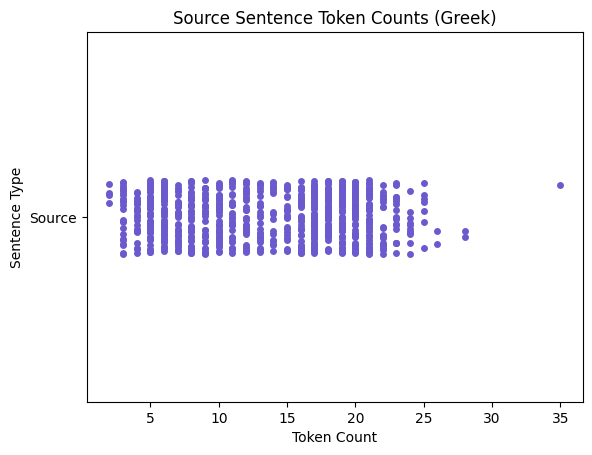

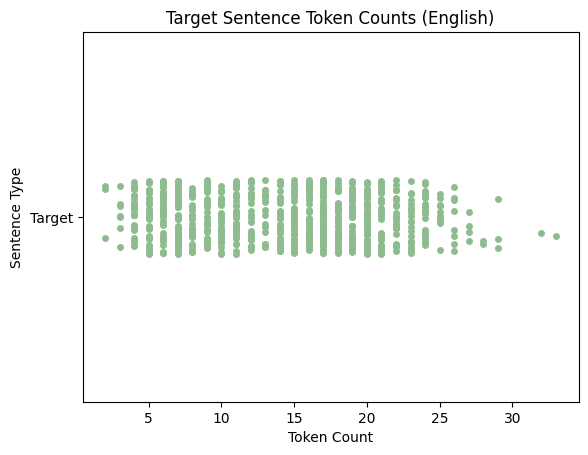

In [24]:
content['Source Token Count'] = [len(nlp_en(sentence)) for sentence in content.iloc[:, 2]]
content['Target Token Count'] = [len(nlp_el(sentence)) for sentence in content.iloc[:, 3]]

source_frame = pd.DataFrame({'Sentence Type': ['Source'] * len(content), 'Token Count': content['Source Token Count']})
target_frame = pd.DataFrame({'Sentence Type': ['Target'] * len(content), 'Token Count': content['Target Token Count']})

plt.figure()
sb.stripplot(data=source_frame, y="Sentence Type", x="Token Count", color="slateblue", dodge=False)
plt.title('Source Sentence Token Counts (Greek)')
plt.show()

plt.figure()
sb.stripplot(data=target_frame, y="Sentence Type", x="Token Count", color="darkseagreen", dodge=False)
plt.title('Target Sentence Token Counts (English)')
plt.show()